# 기본 유틸리티 설치

In [ ]:
# diffusers : stable diffusion 관련 라이브러리, StableDiffusionInpaintPipeline, UNet2DConditionModel, AutoencoderKL, UniPCMultistepScheduler 임포트
# transformers : 텍스트 인코더 CLIPTextModel, CLIPTokenizer 임포트, 즉 프롬프트 텍스트를 디퓨전이 이해하게 바꿔주기 위해 사용
# peft : Lora 적용을 위한 라이브러리 LoraConfig, get_peft_model, PeftModel
# accelerate : 디퓨전, 트랜스포머 모델을 gpu 에 올릴 때 내부적으로 요구하는 유틸리티,
# mediapipe : 미디어파잎 라이브러리 FaceLandmarker 임포트 시 사용
# opencv-python-headless : 이미지 읽기, 마스킹, 크롭, 블러 등 픽셀단위의 작용이 필요할 때 사용
# safetensors : 로라 가중치를 저장할때 쓰이는 파일 포멧
# onnxruntime : BiSeNet 얼굴 파싱 모델이 .onnx로 저장되어있기 때문에 필요
!pip install -q diffusers transformers peft accelerate mediapipe opencv-python-headless safetensors onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 6.7 MB/s eta 0:00:00


# 드라이브 연결

In [ ]:
import os
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


## 어떤걸 학습할 것인지 입력(학습할 때 여기만 바꾸면 됨!)

In [ ]:
celeb = input('학습할 연예인 명을 영어로 입력(소문자로): ')
data_folder_name = input('학습데이터 폴더명 입력 (고윤정_llm 으로 저장했으면 \'고윤정\' 입력): ')

학습할 연예인 명을 영어로 입력(소문자로): iu
학습데이터 폴더명 입력 (고윤정_llm 으로 저장했으면 '고윤정' 입력): 아이유


## 본 코드 시작

In [ ]:
root = "/content/drive/MyDrive/eyebrows" # 우리 루트
cel_name = f'{data_folder_name}_llm' # 데이터 폴더명
trigger = f'{celeb} style eyebrows' # 연예인 이름 트리거 단어
lora_name = f'{celeb}_llm' # 최종으로 학습된 로라 가중치 폴더명

# 학습데이터 경로 train_dir
train_dir = os.path.join(root, 'data','actor_raw_data', cel_name)

# 로라 학습결과 저장 경로
save_dir = os.path.join(root,'lora_checkpoint',lora_name)

# 다른 과정들은 코랩 로컬 디스크에서 돌아가게 함, 즉 학습 종료하면 사라짐
work_dir = '/content/work'

import glob # 패턴으로 파일목록을 자동으로 찾기 위함
image_exts = ("*.png", "*.jpg", "*.jpeg") # 우리가 사용할 확장자

# 해당 확장자를 가진 모든 파일들을 모아 경로를 리스트 형태로 힙치기
train_img = sorted(sum((glob.glob(os.path.join(train_dir,ext)) for ext in image_exts),[]))

# 사진 개수 출력
len(train_img)


30

# MediaPipe 와 BiseNet 준비
### 이미 우리가 다운로드 받아놓은 경로에서 가져오면 됨

In [ ]:
import cv2
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt

# 미디어 파잎 랜드마크 저장 위치
media_dir = os.path.join(root,'mediapipe_bisenet_utils','face_landmarker.task')

# 바이즈넷 정보 저장 위치
bise_dir = os.path.join(root,'mediapipe_bisenet_utils','resnet18.onnx')

# 경로 출력
print(media_dir)
print(bise_dir)

/content/drive/MyDrive/eyebrows/mediapipe_bisenet_utils/face_landmarker.task
/content/drive/MyDrive/eyebrows/mediapipe_bisenet_utils/resnet18.onnx


# 미디어파잎 좌표

In [ ]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# 미디어파잎에서 얼굴 위치 객체를 탐지하는 코드
_detector = None
def _get_detector():
    global _detector
    if _detector is None:
        options = vision.FaceLandmarkerOptions(
            base_options=python.BaseOptions(
                model_asset_path=media_dir,
                delegate=python.BaseOptions.Delegate.CPU,
            ),
            num_faces=1,
        )
        _detector = vision.FaceLandmarker.create_from_options(options)
    return _detector

In [ ]:
# 눈썹과 눈의 좌표
left_brow = [156,70,63,105,66,107,221,222,223,224,225,113,124]
right_brow = [383,300,293,334,296,336,441,442,443,444,445,342,353]
left_eye = [33,7,163,144,145,153,154,155,133,173,157,158,159,160,161,246]
right_eye = [362,382,381,380,374,373,390,249,263,466,388,387,386,385,384,398]

# 랜드마크 추출 코드
def get_landmarks(img):
  h,w = img.shape[:2] # 사진의 가로, 세로 길이

  # mediapipe 의 image 객체 형성
  # image 객체를 생성하는 이유 : 우리의 이미지에서 눈썹과 눈의 좌표를 미디어파잎에게 맡길때 미디어 파잎은 Image 객체만 받음
  mp_img = mp.Image(
      image_format = mp.ImageFormat.SRGB, # 이미지 색상 순서는 rgb 순
      data = cv2.cvtColor(img,cv2.COLOR_BGR2RGB), # 오픈 cv 는 bgr 순이므로 rgb 로 변환
  )

  # 모든 얼굴의 랜드마크 리스트 추출 객체
  result = _get_detector().detect(mp_img)

  # res.face_landmarks = [ [Face 1 랜드마크들],[Face 2 랜드마크들], ...]
  if not result.face_landmarks:
    return None
  landmarks = result.face_landmarks[0] # 첫번째 얼굴의 랜드마크 468개의 점 (얼굴이 근데 하나밖에 없으니 혹시나 모르니께)
  final_landmarks = np.array([[mark.x*w,mark.y*h] for mark in landmarks], dtype=np.int32) # 정규화된 랜드마크를 사진의 크기에 비례하여 확장
  return final_landmarks

def face_scale(points):
  ''' 얼굴 스케일을 대표하기 위해 눈 사이의 유클리드 거리 사용'''
  return float(np.linalg.norm(points[33]-points[263]))

def dilate_mask(mask, pixels=5):
  ''' 마스크 확장 함수'''
  k = 2 * pixels + 1
  kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k,k))
  mask = cv2.dilate(mask, kernel, iterations=1)
  return mask

def _elongation_filter(mask_u8, min_area=2,max_area=4000, min_aspect=1.6):
  out = np.zeros_like(mask_u8) # 마스크의 크기 만큼의 0으로 채워진 행렬
  contours,_= cv2.findContours(mask_u8,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE) # 컨투어(윤곽선) 찾기


  for c in contours:
    area=cv2.contourArea(c)
    if area < min_area or area > max_area: # 정해진 면적보다 작으면 무시
      continue

    if len(c) >= 5:
      (_,_),(w,h),_=cv2.minAreaRect(c) # 중심좌표, 가로세로길이, 회전각도
      long_side, short_side = max(w,h),max(min(w,h), 1e-3)
      aspect=long_side / short_side

    else:
      x,y,w,h = cv2.boundingRect(c)
      aspect= max(w,h)/max(min(w,h),1)

    if aspect >= min_aspect:
      cv2.drawContours(out,[c],-1,255,thickness=cv2.FILLED)
  return out

def detect_stray_hairs(image_bgr, brow_mask, search_px=18,
                       blackhat_ksizes=(5,9,13,15), thresh=None,
                       use_gabor=True, min_aspect=1.6):
  gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
  search_area = dilate_mask(brow_mask,search_px)
  combined= np.zeros_like(gray,dtype=np.uint8)

  for k in blackhat_ksizes:
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(k,k))
    bh = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    combined = cv2.bitwise_or(combined,bh)

  if use_gabor:
    for theta_deg in range(0, 180, 15):
      theta = np.deg2rad(theta_deg)
      g_kernel=cv2.getGaborKernel((9,9),sigma=2.0, theta = theta, lambd=6.0, gamma=0.5, psi=0 )
      resp = cv2.filter2D(gray, cv2.CV_32F, g_kernel)
      resp = cv2.convertScaleAbs(np.abs(resp))
      combined = cv2.max(combined,resp)

  combined[search_area == 0]=0

  if thresh is None:
    roi_vals = combined[search_area>0]
    if roi_vals.size== 0 or roi_vals.max() == 0:
      return np.zeros_like(gray, dtype=np.uint8)
    thresh_val,_ = cv2.threshold(roi_vals, 0 , 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

  else:
    thresh_vals = thresh
  _,hair = cv2.threshold(combined, thresh_val, 255, cv2.THRESH_BINARY)
  hair[search_area==0]=0
  hair = _elongation_filter(hair, min_aspect=min_aspect)
  return hair



In [ ]:
# 바이즈넷
face_class = {
    "skin": [1], "left_eyebrow": [2], "right_eyebrow": [3], "eyebrows": [2, 3],
    "eyes": [4, 5], "nose": [10], "lips": [11, 12, 13], "hair": [17],
}
_IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
_IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
_bisenet_session = None

def _get_bisenet_session():
    global _bisenet_session
    if _bisenet_session is None:
        import onnxruntime as ort
        available = ort.get_available_providers()
        providers = [p for p in ("CUDAExecutionProvider", "CPUExecutionProvider")
                     if p in available]
        _bisenet_session = ort.InferenceSession(bise_dir, providers=providers)
        print("BiSeNet providers:", _bisenet_session.get_providers())
    return _bisenet_session


def _face_square_crop(pts, image_shape, margin=1.4):
    h, w = image_shape[:2]
    min_x, min_y = pts.min(axis=0)
    max_x, max_y = pts.max(axis=0)
    side = int(max(max_x - min_x, max_y - min_y) * margin)
    side = min(max(side, 1), w, h)
    cx, cy = (min_x + max_x) // 2, (min_y + max_y) // 2
    x1 = int(np.clip(cx - side // 2, 0, w - side))
    y1 = int(np.clip(cy - side // 2, 0, h - side))
    return x1, y1, side


def bisenet_parse(img_bgr, pts=None):
    h, w = img_bgr.shape[:2]
    if pts is not None:
        x1, y1, side = _face_square_crop(pts, img_bgr.shape)
        face = img_bgr[y1:y1+side, x1:x1+side]
    else:
        x1, y1 = 0, 0
        face = img_bgr
    rgb = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
    interp = cv2.INTER_AREA if face.shape[0] > 512 else cv2.INTER_LINEAR
    rgb = cv2.resize(rgb, (512, 512), interpolation=interp)
    x = rgb.astype(np.float32) / 255.0
    x = (x - _IMAGENET_MEAN) / _IMAGENET_STD
    x = np.transpose(x, (2, 0, 1))[None]
    sess = _get_bisenet_session()
    out = sess.run(None, {sess.get_inputs()[0].name: x})[0]
    cls512 = out.squeeze(0).argmax(0).astype(np.uint8)
    fh, fw = face.shape[:2]
    cls = cv2.resize(cls512, (fw, fh), interpolation=cv2.INTER_NEAREST)
    full = np.zeros((h, w), dtype=np.uint8)
    full[y1:y1+fh, x1:x1+fw] = cls
    return full


def bisenet_part_mask(img_bgr, parts=("eyebrows",), pts=None):
    cls_map = bisenet_parse(img_bgr, pts=pts)
    ids = []
    for p in parts:
        ids += face_class[p.lower()]
    return (np.isin(cls_map, ids).astype(np.uint8)) * 255


def get_brow_mask(image_bgr, dilate_px=None, eye_guard_px=3, pts=None,
                  use_bisenet=True, dilate_ratio=0.06, eye_guard_ratio=0.09,
                  detect_hair=True, hair_search_px=18, hair_thresh=None):
    """눈썹 영역만 255인 마스크 (추론 노트북과 동일 로직).
    얼굴 랜드마크 검출 실패 시 BiSeNet 단독으로 폴백한다."""
    if pts is None:
        pts = get_landmarks(image_bgr)

    if pts is None:
        # 폴백: MediaPipe 실패 → BiSeNet 단독 (눈 가드/얼굴 비례 없음, 고정 dilate)
        mask = bisenet_part_mask(image_bgr, parts=("eyebrows",), pts=None)
        if mask.max() == 0:
            return None
        mask = dilate_mask(mask, 6)
        if detect_hair:
            stray = detect_stray_hairs(image_bgr, mask, search_px=hair_search_px, thresh=hair_thresh)
            mask = cv2.bitwise_or(mask, stray)
        return mask

    scale = face_scale(pts)
    if dilate_px is None:
        dilate_px = max(1, round(dilate_ratio * scale))

    if eye_guard_px is None:
        eye_guard_px = max(1, round(eye_guard_ratio * scale))

    mask = np.zeros(image_bgr.shape[:2], dtype=np.uint8)
    cv2.fillPoly(mask, [pts[left_brow], pts[right_brow]], 255)

    if use_bisenet:
        try:
            bs = bisenet_part_mask(image_bgr, parts=("eyebrows",), pts=pts)
            mask = cv2.bitwise_or(mask, bs)
        except Exception as e:
            print(f"[warn] BiSeNet 사용 불가 → MediaPipe 단독: {e}")

    if dilate_px > 0:
        mask = dilate_mask(mask, dilate_px)

    if detect_hair:
        stray = detect_stray_hairs(image_bgr, mask, search_px=hair_search_px, thresh=hair_thresh)
        mask = cv2.bitwise_or(mask, stray)

    eye_guard = np.zeros(image_bgr.shape[:2], dtype=np.uint8)
    cv2.fillPoly(eye_guard, [pts[left_eye], pts[right_eye]], 255)
    if eye_guard_px > 0:
        eye_guard = dilate_mask(eye_guard, eye_guard_px)
    mask[eye_guard > 0] = 0
    return mask

print("마스크 유틸 준비 완료")


마스크 유틸 준비 완료


# 마스크 와 학습용 이미지 생성

In [ ]:
import shutil
import torch

if os.path.isdir(work_dir):
  shutil.rmtree(work_dir)

for sub in ('mask','white_background','padded','overlay'):
  os.makedirs(os.path.join(work_dir,sub),exist_ok=True)

ok, failed = [],[]
for i, path in enumerate(train_img):
  stem = os.path.splitext(os.path.basename(path))[0]
  img = cv2.imread(path)
  if img is None:
    failed.append(stem)
    continue
  mask = get_brow_mask(img)

  if mask is None or mask.max()==0: # 눈썹검출 (1) 이 아예없는거
    failed.append(stem)
    continue

  # 1) 눈썹마스크
  cv2.imwrite(os.path.join(work_dir,'mask',f'{stem}_mask.png'),mask)

  # 2) 눈썹 밖은 흰색으로 칠하는 이미지(white_background)
  white_bg = img.copy()
  white_bg[mask == 0]= 255
  cv2.imwrite(os.path.join(work_dir,'white_background',f'{stem}_white.png'),white_bg)

  # 3) 확장 마스크
  cv2.imwrite(os.path.join(work_dir, "padded", f"{stem}_padded.png"),dilate_mask(mask, 5))

  # 4) 오버레이
  overlay = img.copy()
  overlay[mask > 0] = (overlay[mask > 0] * 0.5 + np.array([0, 0, 255]) * 0.5).astype(np.uint8) # 원래사진과 마스크 합성
  cv2.imwrite(os.path.join(work_dir, "overlay", f"{stem}_overlay.jpg"), overlay)

  ok.append(stem)

# 성공한 거 개수
print(len(ok))

BiSeNet providers: ['CPUExecutionProvider']
30


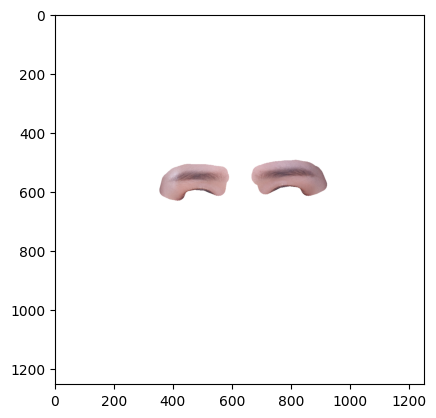

In [ ]:
#시험삼아 추출
overlays = sorted(glob.glob(os.path.join(work_dir, "overlay", "*.jpg")))[0]
whites   = sorted(glob.glob(os.path.join(work_dir, "white_background", "*.png")))[0]

plt.imshow(cv2.cvtColor(cv2.imread(overlays),cv2.COLOR_BGR2RGB))
plt.imshow(cv2.cvtColor(cv2.imread(whites),cv2.COLOR_BGR2RGB))

# 증강 및 크롭 함수들

In [ ]:
from torch.utils.data import Dataset, DataLoader

def augment(img, mask):

  ''' 50퍼센트의 확률로, 이미지와 마스크를 뒤집음
      50퍼센트의 확률로, 랜덤 밝기 조절 '''

  if np.random.rand() > 0.5:
    img = cv2.flip(img, 1)
    mask = cv2.flip(mask, 1)

  if np.random.rand() > 0.5:
    alpha = np.random.uniform(0.9, 1.1)
    beta = np.random.randint(-15, 16)
    img = np.clip(img.astype(np.float32) * alpha + beta, 0, 255).astype(np.uint8)

  return img, mask


def mask_bbox(mask):
  ys, xs = np.where(mask > 0)  # 눈썹부위의 좌표 구하기
  if len(xs) == 0 or len(ys) == 0:
    return None
  return xs.min(), xs.max(), ys.min(), ys.max()


def clamp_square(x1, y1, side, w, h):
  side = int(min(side, w, h))
  x1 = int(np.clip(x1, 0, w - side))
  y1 = int(np.clip(y1, 0, h - side))
  return x1, y1, side, side


def zoom_crop(mask, image_shape, padding_ratio=1, min_size=1):
  ''' 눈썹을 중심으로 하는 바운딩 정사각형 만들기 '''
  h, w = image_shape[:2]
  bb = mask_bbox(mask)

  if bb is None:
    return (0, 0, w, h)

  x1, x2, y1, y2 = bb
  side = max(max(x2 - x1, y2 - y1) * padding_ratio, min_size)
  cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
  return clamp_square(cx - side // 2, cy - side // 2, side, w, h)


def rd_zoom_crop(mask, image_shape, min_padding=1, max_padding=1.3, max_shift=15):
  ''' 랜덤으로 눈썹을 중심으로 하는 바운딩 정사각형 만들기 '''
  h, w = image_shape[:2]
  bb = mask_bbox(mask)
  if bb is None:
    side = min(h, w)
    return (w // 2 - side // 2, h // 2 - side // 2, side, side)
  min_x, max_x, min_y, max_y = bb
  padding_ratio = np.random.uniform(min_padding, max_padding)
  side = int(max(max_x - min_x, max_y - min_y) * padding_ratio)
  cx = (min_x + max_x) // 2 + np.random.randint(-max_shift, max_shift + 1)
  cy = (min_y + max_y) // 2 + np.random.randint(-max_shift, max_shift + 1)
  return clamp_square(cx - side // 2, cy - side // 2, side, w, h)

def actor_face_crop(mask, image_shape, padding_ratio=2.25, vertical_offset_ratio=0.08):
    h, w = image_shape[:2]
    bb = mask_bbox(mask)
    if bb is None:
        return (0, 0, w, h)
    min_x, max_x, min_y, max_y = bb
    bw = max_x - min_x
    side = int(bw * padding_ratio)
    cx = (min_x + max_x) // 2
    cy = (min_y + max_y) // 2 + int(bw * vertical_offset_ratio)
    return clamp_square(cx - side // 2, cy - side // 2, side, w, h)


def random_actor_face_crop(mask, image_shape, min_padding=1.5, max_padding=3, max_shift=30):
    h, w = image_shape[:2]
    bb = mask_bbox(mask)
    if bb is None:
        return (0, 0, w, h)
    min_x, max_x, min_y, max_y = bb
    bw = max_x - min_x
    side = int(bw * np.random.uniform(min_padding, max_padding))
    cx = (min_x + max_x) // 2 + np.random.randint(-max_shift, max_shift + 1)
    cy = ((min_y + max_y) // 2 + int(bw * np.random.uniform(0.06, 0.10))
          + np.random.randint(-max_shift, max_shift + 1))
    return clamp_square(cx - side // 2, cy - side // 2, side, w, h)



def apply_crop(image, crop_info, target_size=512, is_mask=True):
    x, y, cw, ch = crop_info
    cropped = image[y:y+ch, x:x+cw]
    if cropped.shape[:2] != (target_size, target_size):
        interp = cv2.INTER_NEAREST if is_mask else cv2.INTER_LANCZOS4
        cropped = cv2.resize(cropped, (target_size, target_size), interpolation=interp)
    return cropped


def square_dilate(mask, pixels):
    """원본 train_lora.py의 dilate (정사각 커널)"""
    kernel = np.ones((pixels, pixels), np.uint8)
    return cv2.dilate(mask, kernel, iterations=1)

# 데이터셋

In [ ]:
class eyebrow_dataset(Dataset):
    def __init__(self, work_dir, raw_dir, trigger, size=512, augment=True):
        self.size = size
        self.augment = augment
        self.trigger = trigger
        self.samples = []
        raw_map = {}
        for e in ('*.png', '*.jpg', '*.jpeg'):
            for path in glob.glob(os.path.join(raw_dir, e)):
                raw_map[os.path.splitext(os.path.basename(path))[0]] = path

        skipped = []
        for f in sorted(os.listdir(os.path.join(work_dir, "white_background"))):
            stem = f.replace("_white.png", "")
            wt = os.path.join(work_dir, "white_background", f"{stem}_white.png")
            mk = os.path.join(work_dir, "mask", f"{stem}_mask.png")
            pd = os.path.join(work_dir, "padded", f"{stem}_padded.png")
            raw = raw_map.get(stem)

            self.samples.append({'img': wt, 'mask': mk, 'white': True})

            if raw is None:
                skipped.append(stem)
                continue

            self.samples.append({'img': raw, 'mask': mk, 'white': False})
            self.samples.append({'img': raw, 'mask': pd, 'white': False})

        print(f"numbers of samples : {len(self.samples)}")
        if skipped:
            print(f"[warn] 원본(raw) 파일을 못 찾아 배우 얼굴 샘플을 건너뛴 stem {len(skipped)}개: {skipped}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        img = cv2.cvtColor(cv2.imread(sample['img']), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(sample['mask'], cv2.IMREAD_GRAYSCALE)
        _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

        if self.augment:
            img, mask = augment(img, mask)
            if sample['white']:
                ci = rd_zoom_crop(mask, img.shape)
            else:
                ci = random_actor_face_crop(mask, img.shape)
        else:
            if sample['white']:
                ci = zoom_crop(mask, img.shape)
            else:
                ci = actor_face_crop(mask, img.shape)

        img = apply_crop(img, ci, self.size)
        mask = apply_crop(mask, ci, self.size, is_mask=True)

        if sample['white']:
            final_mask = square_dilate(mask, 5)
            prompt = f"{self.trigger}, isolated on white background"
        else:
            final_mask = square_dilate(mask, 15)
            prompt = f"{self.trigger} on a face, high quality, realistic"

        return {
            "pixel_values": torch.from_numpy(img).permute(2, 0, 1).float() / 127.5 - 1.0,
            "masks": torch.from_numpy(final_mask).unsqueeze(0).float() / 255.0,
            "prompt": prompt,
        }

numbers of samples : 90
prompt      : iu style eyebrows, isolated on white background
pixel_values: (3, 512, 512)  masks: (1, 512, 512)


/tmp/ipykernel_617/1551114839.py:14: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_617/1551114839.py:14: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_617/1551114839.py:14: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_617/1551114839.py:14: UserWarning: Glyph 50669 (\N{HANGUL SYLLABLE YEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.canvas.prin

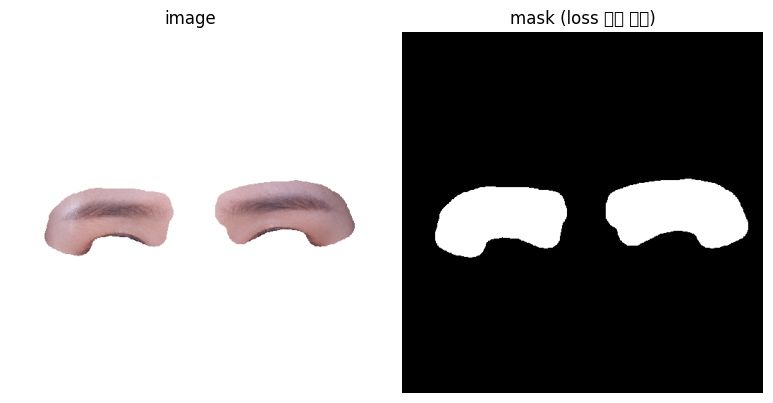

In [ ]:
# 데이터셋 확인 (학습 전 필수 점검)
check_ds = eyebrow_dataset(work_dir, train_dir, trigger, augment=True)
assert len(check_ds) > 0

sample = check_ds[0]
print("prompt      :", sample["prompt"])
print("pixel_values:", tuple(sample["pixel_values"].shape), " masks:", tuple(sample["masks"].shape))

img_vis = ((sample["pixel_values"].permute(1, 2, 0).numpy() + 1) * 127.5).clip(0, 255).astype("uint8")
mask_vis = (sample["masks"][0].numpy() * 255).astype("uint8")
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_vis); axes[0].set_title("image"); axes[0].axis("off")
axes[1].imshow(mask_vis, cmap="gray"); axes[1].set_title("mask (loss 적용 영역)"); axes[1].axis("off")
plt.tight_layout(); plt.show()

In [ ]:
!pip install -q -U "torchao>=0.16.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 63.9 MB/s eta 0:00:00


# 학습

In [ ]:
import os

train_celeb   = cel_name
output = lora_name                 # 최종 LoRA 폴더명

img_dir   = os.path.join(root, "data", "actor_raw_data", train_celeb)
lora_dir = os.path.join(root, "lora_checkpoint", output)
work_dir  = "/content/work"                  # 전처리 결과(로컬 디스크, 세션 종료 시 삭제됨)

import glob
image_exts = ("*.png", "*.jpg", "*.jpeg")
images = sorted(sum((glob.glob(os.path.join(img_dir, e)) for e in image_exts), []))
print(f"nunmber of images : {len(images)}")
print("save directory:", lora_dir)


nunmber of images : 30
save directory: /content/drive/MyDrive/eyebrows/lora_checkpoint/iu_llm


In [ ]:
import math
from diffusers import UNet2DConditionModel, AutoencoderKL, DDPMScheduler
from diffusers.optimization import get_scheduler
from transformers import CLIPTextModel, CLIPTokenizer
from peft import LoraConfig, get_peft_model
from tqdm.auto import tqdm
import torch.nn.functional as F

base_model  = "emilianJR/epiCRealism"
max_step = 2000
saving_step      = 250
batch_size      = 2
learning_rate   = 5e-5
text_encoder_learning_rate = 1e-5
warmup_steps = 100
max_gradnorm   = 1.0
offset_noise    = 0.1
min_snr_gamma   = 5.0

device = "cuda"
assert torch.cuda.is_available(), "not using gpu."
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

print("loading the model..")


tokenizer    = CLIPTokenizer.from_pretrained(base_model, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(base_model, subfolder="text_encoder").to(device)
vae          = AutoencoderKL.from_pretrained(base_model, subfolder="vae").to(device)
unet         = UNet2DConditionModel.from_pretrained(base_model, subfolder="unet").to(device)
vae.requires_grad_(False)


unet = get_peft_model(unet, LoraConfig(
    r=64, lora_alpha=64, target_modules=["to_k", "to_q", "to_v", "to_out.0"], bias="none"))

text_encoder = get_peft_model(text_encoder, LoraConfig(
    r=16, lora_alpha=16, target_modules=["q_proj", "k_proj", "v_proj", "out_proj"], bias="none"))
unet.print_trainable_parameters()


dataset = eyebrow_dataset(work_dir, train_dir, trigger, augment=True)
loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True)
EPOCHS  = math.ceil(max_step / len(loader))

# 실제로 학습되는 LoRA 파라미터만 optimizer에 전달
unet_trainable_params = [p for p in unet.parameters() if p.requires_grad]
text_encoder_trainable_params = [p for p in text_encoder.parameters() if p.requires_grad]
all_trainable_params = unet_trainable_params + text_encoder_trainable_params

optimizer = torch.optim.AdamW([
    {"params": unet_trainable_params, "lr": learning_rate},
    {"params": text_encoder_trainable_params, "lr": text_encoder_learning_rate},
])
lr_scheduler = get_scheduler("cosine", optimizer=optimizer,
                             num_warmup_steps= warmup_steps, num_training_steps=max_step)
noise_scheduler = DDPMScheduler.from_pretrained(base_model, subfolder="scheduler")

print(f" {len(dataset)} samples, {max_step} step ({EPOCHS} epochs)")


Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


loading the model..


tokenizer_config.json:   0%|          | 0.00/737 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

...

unet/diffusion_pytorch_model.safetensors: reconstructing file:   0%|          |  0.00B / 3.44GB            

unet/diffusion_pytorch_model.safetensors: downloading bytes:           |  0.00B            

trainable params: 12,754,944 || all params: 872,275,908 || trainable%: 1.4623
numbers of samples : 90


scheduler_config.json:   0%|          | 0.00/528 [00:00<?, ?B/s]

 90 samples, 2000 step (45 epochs)


In [ ]:
def save_lora(dst):
    os.makedirs(dst, exist_ok=True)
    unet.save_pretrained(os.path.join(dst, "unet"))
    text_encoder.save_pretrained(os.path.join(dst, "text_encoder"))

#  학습 모드 설정
unet.train()  # UNet을 훈련 모드로 전환
text_encoder.train()  # Text Encoder를 훈련 모드로 전환
global_step = 0  # 총 훈련 스텝 카운터
recent_losses = []  # 최근 손실값 기록

# Epoch 루프 시작
for epoch in range(EPOCHS):
    if global_step >= max_step:  # 최대 스텝 도달 시 종료
        break
    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    # 배치별 처리 시작
    for batch in pbar:
        if global_step >= max_step:  # 최대 스텝 도달 시 종료
            break

        # 배치 데이터 로드 및 GPU로 이동
        pixel_values = batch["pixel_values"].to(device)  # 이미지 (512x512)
        masks = batch["masks"].to(device)  # 눈썹 마스크

        # 이미지를 잠재 공간(Latent Space)으로 변환
        # VAE Encoder를 사용해 512x512 이미지 → 64x64 잠재 벡터로 압축
        latents = vae.encode(pixel_values).latent_dist.sample().detach() * 0.18215

        # 마스크를 잠재 공간 크기로 조정
        # 마스크도 512x512 → 64x64으로 리사이즈 (UNet 입력 크기에 맞춤)
        mask_latent = F.interpolate(masks, size=(latents.shape[2], latents.shape[3]))

        # 노이즈 생성 (확산 모델의 핵심)
        # 잠재벡터와 같은 크기의 랜덤 노이즈 생성
        noise = torch.randn_like(latents)

        #  Offset 노이즈 추가 (훈련 안정화)
        if offset_noise:
            noise += offset_noise * torch.randn(latents.shape[0], latents.shape[1], 1, 1, device=device)

        # 타임스텝 샘플링 (0~999 중 랜덤)
        # 확산 과정의 어느 단계인지 결정 (처음/중간/끝)
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps,
                                  (latents.shape[0],), device=device).long()

        # 잠재벡터에 노이즈 추가
        # 잠재벡터 + t시점의 노이즈 = 노이즈가 섞인 잠재벡터
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        # 프롬프트 텍스트 인코딩
        # 프롬프트를 토큰으로 변환
        inputs = tokenizer(batch["prompt"], padding="max_length",
                           max_length=tokenizer.model_max_length,
                           truncation=True, return_tensors="pt").to(device)

        # 토큰을 텍스트 임베딩 벡터로 변환 (Text Encoder LoRA 학습됨)
        encoder_hidden_states = text_encoder(inputs.input_ids)[0]

        # UNet으로 노이즈 예측
        # 입력: 노이즈섞인잠재벡터 + 타임스텝 + 텍스트임베딩
        # 출력: 모델이 예측한 노이즈 (UNet LoRA 학습됨)
        model_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample

        # Min-SNR-Gamma 가중치 계산 (손실 안정화)
        # Signal-to-Noise Ratio 기반 가중치로 학습 안정화
        alphas_cumprod = noise_scheduler.alphas_cumprod.to(device)
        sigmas = ((1 - alphas_cumprod) / alphas_cumprod) ** 0.5
        snr = (sigmas ** -2).index_select(0, timesteps)
        w = torch.stack([snr, min_snr_gamma * torch.ones_like(timesteps)], dim=1).min(dim=1)[0] / snr

        # 손실 계산
        # 모델이 예측한 노이즈 vs 실제 노이즈의 차이 제곱
        loss_el = (model_pred.float() - noise.float()) ** 2

        # 마스크를 적용해 눈썹 부분만 손실 계산
        # mask_latent: [B, 1, H, W], loss_el: [B, 4, H, W]
        # broadcasting으로 4개 latent channel에 동일한 mask가 적용됨
        masked_loss_el = loss_el * mask_latent

        # 중요: 전체 latent(4x64x64) 평균이 아니라 '실제 mask 내부'의 평균 오차로 정규화
        # 이렇게 해야 작은 눈썹 mask와 넓은 padded mask가 단순 면적 차이 때문에
        # 서로 다른 학습 강도를 갖는 문제를 줄일 수 있음
        mask_area = mask_latent.sum(dim=[1, 2, 3]) * loss_el.shape[1]
        masked_loss = (
            masked_loss_el.sum(dim=[1, 2, 3])
            / mask_area.clamp(min=1e-8)
        )

        # Min-SNR 가중치를 sample별 masked loss에 적용한 뒤 batch 평균
        loss = (masked_loss * w).mean()

        # 역전파 (Backpropagation)
        loss.backward()  # 손실에 대한 그래디언트 계산

        # 그래디언트 클리핑 (수치 안정성)
        # UNet LoRA + Text Encoder LoRA를 함께 clipping
        torch.nn.utils.clip_grad_norm_(all_trainable_params, max_gradnorm)

        # 가중치 업데이트
        optimizer.step()  # Adam 옵티마이저로 LoRA 파라미터 업데이트
        lr_scheduler.step()  # 학습률 스케줄 업데이트 (코사인 감쇠)
        optimizer.zero_grad()  # 그래디언트 초기화

        # 진행 상황 업데이트
        global_step += 1
        recent_losses.append(loss.item())
        pbar.set_postfix({"loss": f"{loss.item():.4f}",
                          "mask": f"{mask_latent.mean().item():.3f}",
                          "lr": f"{lr_scheduler.get_last_lr()[0]:.1e}",
                          "step": f"{global_step}/{max_step}"})

        # 주기적 체크포인트 저장 (250스텝마다)
        # stochastic loss의 최저점만 저장하면 시각적으로 더 좋은 중간 모델을 놓칠 수 있으므로
        # 소규모 데이터셋에서는 모든 구간 체크포인트를 남겨 직접 비교할 수 있게 함
        if global_step % saving_step == 0:
            avg_loss = sum(recent_losses) / len(recent_losses)
            recent_losses = []
            ckpt = os.path.join(lora_dir, "checkpoints", f"checkpoint-{global_step}")
            save_lora(ckpt)
            print(f"checkpoint 저장 (avg_loss={avg_loss:.4f}) → {ckpt}")

# ===== 단계 19: 최종 저장 =====
save_lora(lora_dir)  # 최종 LoRA 모델 저장
print(f" LoRA 저장 위치: {lora_dir}")

Epoch 1/45:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 2/45:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 3/45:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 4/45:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 5/45:   0%|          | 0/45 [00:00<?, ?it/s]

...

Epoch 42/45:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 43/45:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 44/45:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 45/45:   0%|          | 0/45 [00:00<?, ?it/s]

checkpoint 저장 (avg_loss=0.0582) → /content/drive/MyDrive/eyebrows/lora_checkpoint/iu_llm/checkpoints/checkpoint-2000
 LoRA 저장 위치: /content/drive/MyDrive/eyebrows/lora_checkpoint/iu_llm


In [ ]:
import os

print("unet 존재:", "unet" in globals())
print("text_encoder 존재:", "text_encoder" in globals())
print("accelerator 존재:", "accelerator" in globals())

unet 존재: True
text_encoder 존재: True
accelerator 존재: False


In [ ]:
# 기존 celeb_eyebrows_* 체크포인트와 동일한 구조인지 확인
need = [
    os.path.join(lora_dir, "unet", "adapter_config.json"),
    os.path.join(lora_dir, "unet", "adapter_model.safetensors"),
    os.path.join(lora_dir, "text_encoder", "adapter_config.json"),
    os.path.join(lora_dir, "text_encoder", "adapter_model.safetensors"),
]
for p in need:
    size = os.path.getsize(p) / 1024 / 1024 if os.path.exists(p) else 0
    print(f"{'✅' if os.path.exists(p) else '❌'} {p.replace(root + os.sep, '')} ({size:.1f} MB)")
assert all(os.path.exists(p) for p in need), "저장이 완료되지 않았습니다."
print("\n🎉 추론 노트북에서 바로 사용할 수 있습니다.")

✅ lora_checkpoint/iu_llm/unet/adapter_config.json (0.0 MB)
✅ lora_checkpoint/iu_llm/unet/adapter_model.safetensors (48.7 MB)
✅ lora_checkpoint/iu_llm/text_encoder/adapter_config.json (0.0 MB)
✅ lora_checkpoint/iu_llm/text_encoder/adapter_model.safetensors (4.5 MB)

🎉 추론 노트북에서 바로 사용할 수 있습니다.
